<a href="https://colab.research.google.com/github/DARIOYBETY123/Modulo-4-Deep-Leraning/blob/main/2_3_Deep_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Forma Matricial de la 1ª RedCompletamos las matrices β₀, Ω₀ (capa oculta) y β₁, Ω₁ (capa de salida):

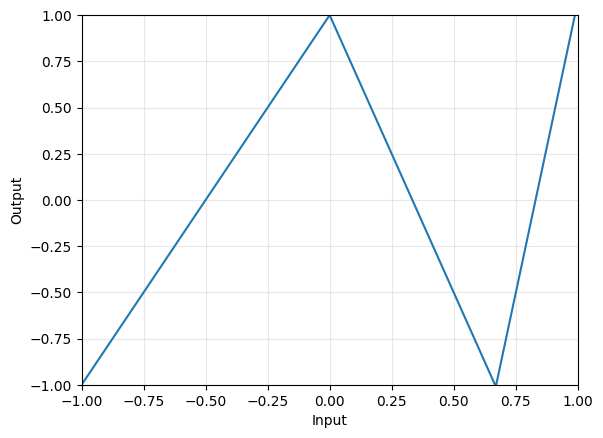

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función ReLU ---
def ReLU(preactivation):
    activation = preactivation.clip(0.0)
    return activation

# --- Función de gráfica CORREGIDA para aceptar dimensiones matriciales ---
def plot_neural(x, y):
    fig, ax = plt.subplots()
    # Transponemos para que las filas coincidan
    ax.plot(x.flatten(), y.flatten())
    ax.set_xlabel('Input'); ax.set_ylabel('Output')
    ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1])
    ax.grid(True, alpha=0.3)
    plt.show()

# === PARÁMETROS ===
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0.0   ; n1_theta_21 =  1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# === DATOS DE ENTRADA ===
n1_in = np.arange(-1, 1, 0.01).reshape([1, -1])  # Forma (1, 200)

# === INICIALIZAR MATRICES ===
beta_0 = np.zeros((3, 1))     # (3, 1) sesgos capa oculta
Omega_0 = np.zeros((3, 1))    # (3, 1) pesos capa oculta
beta_1 = np.zeros((1, 1))      # (1, 1) sesgo salida
Omega_1 = np.zeros((1, 3))     # (1, 3) pesos salida

# === LLENAR VALORES ===
beta_0[0,0] = n1_theta_10   # 0.0
beta_0[1,0] = n1_theta_20   # 0.0
beta_0[2,0] = n1_theta_30   # -0.67

Omega_0[0,0] = n1_theta_11  # -1.0
Omega_0[1,0] = n1_theta_21  #  1.0
Omega_0[2,0] = n1_theta_31  #  1.0

beta_1[0,0] = n1_phi_0       # 1.0
Omega_1[0,0] = n1_phi_1      # -2.0
Omega_1[0,1] = n1_phi_2      # -3.0
Omega_1[0,2] = n1_phi_3      #  9.3

# === PREPARAR DATOS EN FORMA MATRICIAL ===
n_data = n1_in.size
n_dim_in = 1
n1_in_mat = np.reshape(n1_in, (n_dim_in, n_data))  # (1, 200)

# === EJECUTAR RED MATRICIAL ===
h1 = ReLU(beta_0 + np.matmul(Omega_0, n1_in_mat))  # → (3, 200)
n1_out = beta_1 + np.matmul(Omega_1, h1)             # → (1, 200)

# === GRÁFICA — AHORA SÍ FUNCIONA ===
plot_neural(n1_in, n1_out)

Ambas gráficas deben ser idénticas.

Dos Redes Apiladas (Capa Compuesta)

Ahora la salida de la 1ª red alimenta a la 2ª red. Se combinan los parámetros en nuevas matrices:
Regla de composición:
β₁ = sesgo 2ª + peso 2ª × sesgo 1ª
Ω₁ = peso 2ª × peso 1ª

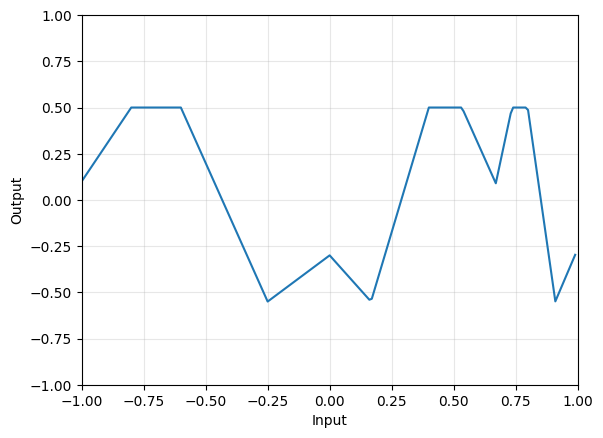

In [ ]:
# Parámetros 2ª red
n2_theta_10 = -0.6 ; n2_theta_11 = -1.0
n2_theta_20 = 0.2  ; n2_theta_21 = 1.0
n2_theta_30 = -0.5 ; n2_theta_31 = 1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# === MATRICES COMPLETADAS ===
beta_0 = np.zeros((3, 1))    # Sesgos capa 1
Omega_0 = np.zeros((3, 1))   # Pesos capa 1
beta_1 = np.zeros((3, 1))    # Sesgos compuestos (capa 2 respecto a entrada)
Omega_1 = np.zeros((3, 3))    # Pesos compuestos
beta_2 = np.zeros((1, 1))     # Sesgo final
Omega_2 = np.zeros((1, 3))    # Pesos finales

# Capa 1 → igual al ejercicio anterior
beta_0[0,0] = n1_theta_10
beta_0[1,0] = n1_theta_20
beta_0[2,0] = n1_theta_30

Omega_0[0,0] = n1_theta_11
Omega_0[1,0] = n1_theta_21
Omega_0[2,0] = n1_theta_31

# Capa compuesta (capa 2 vista desde la entrada)
# βᵢ = θ2ᵢ₀ + θ2ᵢ₁ · φ0
beta_1[0,0] = n2_theta_10 + n2_theta_11 * n1_phi_0   # -0.6 + (-1.0)·1.0 = -1.6
beta_1[1,0] = n2_theta_20 + n2_theta_21 * n1_phi_0   #  0.2 +   1.0 ·1.0 =  1.2
beta_1[2,0] = n2_theta_30 + n2_theta_31 * n1_phi_0   # -0.5 +   1.0 ·1.0 =  0.5

# Ωᵢⱼ = θ2ᵢ₁ · φⱼ  (peso compuesto = producto de pesos)
Omega_1[0,0] = n2_theta_11 * n1_phi_1   # (-1.0)·(-2.0) = 2.0
Omega_1[0,1] = n2_theta_11 * n1_phi_2   # (-1.0)·(-3.0) = 3.0
Omega_1[0,2] = n2_theta_11 * n1_phi_3   # (-1.0)·( 9.3) = -9.3

Omega_1[1,0] = n2_theta_21 * n1_phi_1   # ( 1.0)·(-2.0) = -2.0
Omega_1[1,1] = n2_theta_21 * n1_phi_2   # ( 1.0)·(-3.0) = -3.0
Omega_1[1,2] = n2_theta_21 * n1_phi_3   # ( 1.0)·( 9.3) =  9.3

Omega_1[2,0] = n2_theta_31 * n1_phi_1   # ( 1.0)·(-2.0) = -2.0
Omega_1[2,1] = n2_theta_31 * n1_phi_2   # ( 1.0)·(-3.0) = -3.0
Omega_1[2,2] = n2_theta_31 * n1_phi_3   # ( 1.0)·( 9.3) =  9.3

# Capa de salida
beta_2[0,0] = n2_phi_0                   # 0.5
Omega_2[0,0] = n2_phi_1                   # -1.0
Omega_2[0,1] = n2_phi_2                   # -1.5
Omega_2[0,2] = n2_phi_3                   #  2.0

# Ejecutar red profunda
h1 = ReLU(beta_0 + np.matmul(Omega_0, n1_in_mat))
h2 = ReLU(beta_1 + np.matmul(Omega_1, h1))
n1_out = beta_2 + np.matmul(Omega_2, h2)

# Graficar → DEBE coincidir con la versión escalar apilada
plot_neural(n1_in, n1_out)

La gráfica debe coincidir con shallow_1_1_3(shallow_1_1_3(...)).

Red Profunda de 3 Capas (Tamaños Correctos)

Matriz	Tamaño = (neuronas_salida, neuronas_entrada)
βₗ	(D_salida, 1) — vector columna de sesgos
βₗ	(D_salida, 1) — vector columna de sesgos


Datos:
Entrada: Dᵢ = 4
Capa 1: D₁ = 5 neuronas
Capa 2: D₂ = 2 neuronas
Capa 3: D₃ = 4 neuronas
Salida: Dₒ = 1

In [2]:
# Tamaños definidos
D_i = 4; D_1 = 5; D_2 = 2; D_3 = 4; D_o = 1
n_data = 4

# Datos de entrada aleatorios
x = np.random.normal(size=(D_i, n_data))   # (4, 4)

# === INICIALIZACIÓN CON TAMAÑOS CORRECTOS ===
# Capa 0 → Entrada → Capa 1
beta_0 = np.random.normal(size=(D_1,  D_i))
beta_0 = np.random.normal(size=(D_1, 1))
Omega_0 = np.random.normal(size=(D_1, D_i))

# Capa 1 → Capa 1 → Capa 2
beta_1 = np.random.normal(size=(D_2, 1))
Omega_1 = np.random.normal(size=(D_2, D_1))

# Capa 2 → Capa 2 → Capa 3
beta_2 = np.random.normal(size=(D_3, 1))
Omega_2 = np.random.normal(size=(D_3, D_2))

# Capa 3 → Capa 3 → Salida
beta_3 = np.random.normal(size=(D_o, 1))
Omega_3 = np.random.normal(size=(D_o, D_3))

# === EJECUTAR RED ===
h1 = ReLU(beta_0 + np.matmul(Omega_0, x))
h2 = ReLU(beta_1 + np.matmul(Omega_1, h1))
h3 = ReLU(beta_2 + np.matmul(Omega_2, h2))
y = beta_3 + np.matmul(Omega_3, h3)

# === VERIFICACIONES ===
if h1.shape != (D_1, n_data): print(" h1 mal")
else: print(" h1 OK")

if h2.shape != (D_2, n_data): print(" h2 mal")
else: print(" h2 OK")

if h3.shape != (D_3, n_data): print(" h3 mal")
else: print(" h3 OK")

if y.shape != (D_o, n_data): print(" Salida mal")
else: print(" Salida OK")

print("\nEntrada:\n", x)
print("\nSalida:\n", y)

 h1 OK
 h2 OK
 h3 OK
 Salida OK

Entrada:
 [[ 0.60516215  0.87890256 -0.63191842 -0.09252083]
 [ 0.31428283 -0.09111832  0.80808645  0.93540277]
 [-0.27165241  0.33693896  0.89653189 -0.09426911]
 [-1.12695868  0.0882321  -0.37919025  0.02073977]]

Salida:
 [[6.58753515 4.13000907 3.73007166 5.61983506]]
